In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("book 2.xlsx")

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
   year   railway     sea   river   auto_bus     air       tram    trolley  \
0  1995  577431.5  7817.0  3594.1  3483173.0  1914.9   821652.3  1358736.9   
1  1996  538568.7  5044.6  2735.9  3304600.0  1724.0   788026.2  1590439.3   
2  1997  500838.8  4311.3  2443.1  2512147.2  1484.5  1265349.2  2388087.6   
3  1998  501428.7  3838.3  2356.5  2403424.6  1163.9  1450735.2  2717998.1   
4  1999  486810.4  3084.3  2269.4  2501707.5  1087.0  1456755.4  2735241.0   

     subway  
0  561012.4  
1  536304.1  
2  507897.0  
3  668456.4  
4  724425.5  


In [2]:
print("\nDataset Shape:")
print(df.shape)

# Remove Duplicate Records
df.drop_duplicates(inplace=True)

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill Numeric Missing Values
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill Categorical Missing Values
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nData Cleaning Completed")


Dataset Shape:
(26, 9)

Missing Values:
year        0
railway     0
sea         0
river       0
auto_bus    0
air         0
tram        0
trolley     0
subway      0
dtype: int64

Data Cleaning Completed


In [3]:
print("\nBasic Statistics:")
print(df.describe()) 
print("\nColumn Information:") 
print(df.info())


Basic Statistics:
              year        railway           sea        river      auto_bus  \
count    26.000000      26.000000     26.000000    26.000000  2.600000e+01   
mean   2007.500000  407824.500000  11857.934615  1546.111538  3.003374e+06   
std       7.648529  126653.115605  15028.172028   894.806411  8.487019e+05   
min    1995.000000   68332.500000     52.600000   256.500000  1.083873e+06   
25%    2001.250000  398649.800000   4494.625000   604.925000  2.427995e+06   
50%    2007.500000  445509.400000   6643.800000  1701.700000  3.183320e+06   
75%    2013.750000  474513.125000   9213.050000  2207.450000  3.693202e+06   
max    2020.000000  577431.500000  45836.000000  3594.100000  4.369126e+06   

                air          tram       trolley         subway  
count     26.000000  2.600000e+01  2.600000e+01      26.000000  
mean    5156.550000  9.450878e+05  1.607972e+06  743352.684615  
std     3572.125665  2.826577e+05  5.904788e+05  130840.813545  
min     1087.00000


Correlation Matrix:
              year   railway       sea     river  auto_bus       air  \
year      1.000000 -0.839162  0.388244 -0.955349 -0.373893  0.871876   
railway  -0.839162  1.000000 -0.142259  0.750551  0.636013 -0.731078   
sea       0.388244 -0.142259  1.000000 -0.414970 -0.199928  0.274012   
river    -0.955349  0.750551 -0.414970  1.000000  0.410044 -0.801581   
auto_bus -0.373893  0.636013 -0.199928  0.410044  1.000000 -0.254136   
air       0.871876 -0.731078  0.274012 -0.801581 -0.254136  1.000000   
tram     -0.775787  0.644500 -0.299401  0.688482  0.213914 -0.730587   
trolley  -0.819275  0.658417 -0.360244  0.713988  0.182152 -0.753776   
subway    0.013991  0.233066  0.005046  0.031593  0.642898  0.084224   

              tram   trolley    subway  
year     -0.775787 -0.819275  0.013991  
railway   0.644500  0.658417  0.233066  
sea      -0.299401 -0.360244  0.005046  
river     0.688482  0.713988  0.031593  
auto_bus  0.213914  0.182152  0.642898  
air      -0.

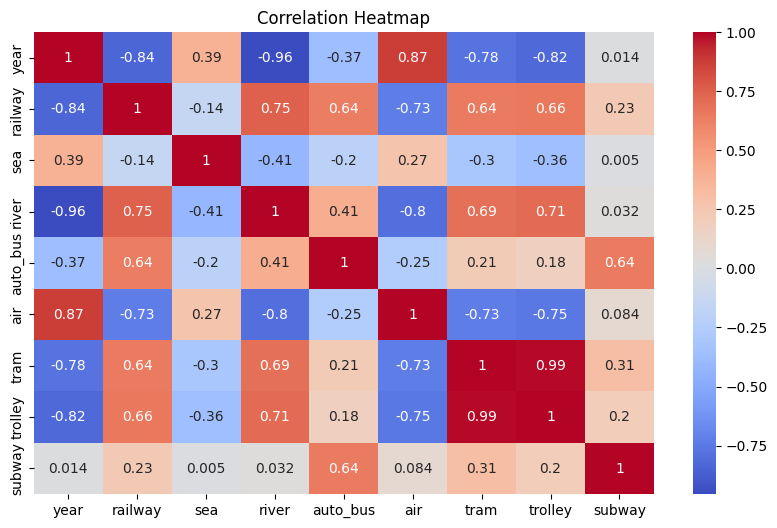

In [4]:
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr() 
print("\nCorrelation Matrix:") 
print(correlation_matrix) 
plt.figure(figsize=(10,6)) 
sns.heatmap( 
    correlation_matrix,
     annot=True,
     cmap="coolwarm" )
plt.title("Correlation Heatmap")
plt.show()

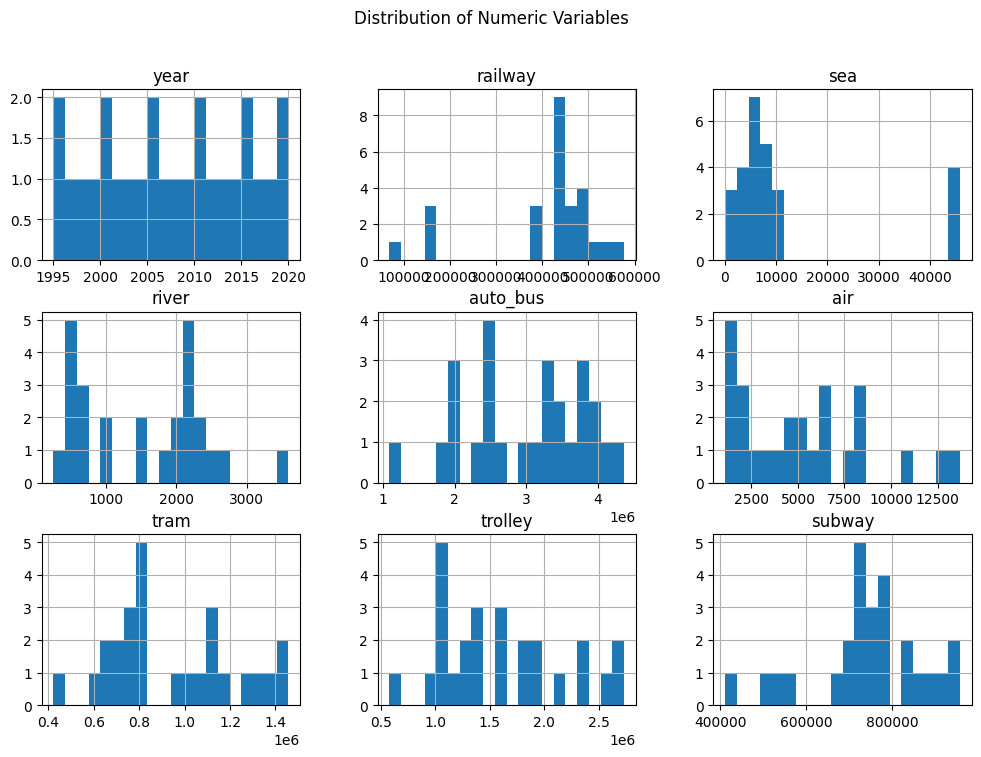

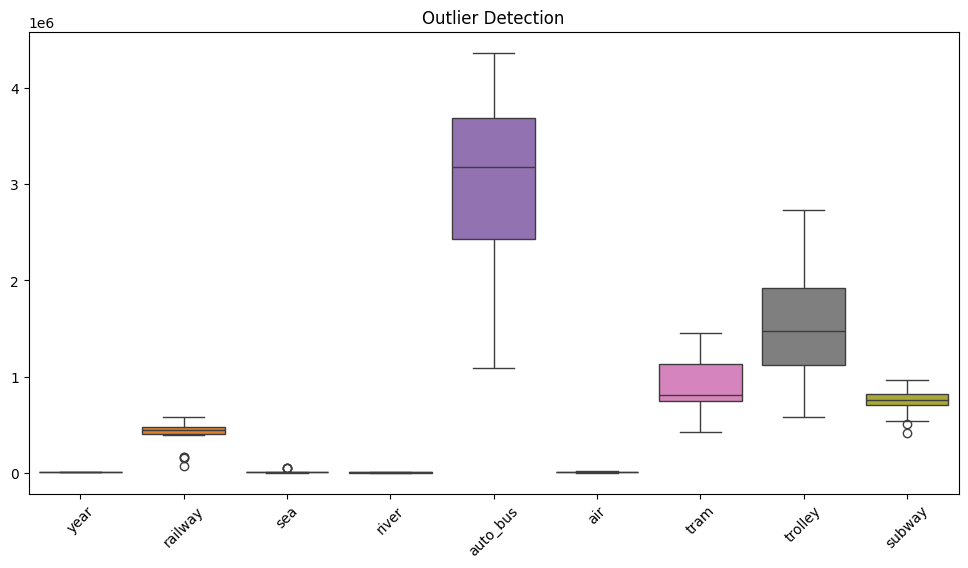

In [5]:
# Histogram 
numeric_df.hist( 
 figsize=(12,8), 
 bins=20 ) 
plt.suptitle("Distribution of Numeric Variables")
plt.show() 
# Boxplot
plt.figure(figsize=(12,6)) 
sns.boxplot(data=numeric_df)
plt.title("Outlier Detection")
plt.xticks(rotation=45)
plt.show()

In [6]:
try:
    pivot_table = pd.pivot_table(
        df,
        values=numeric_cols[0],
        index=categorical_cols[0],
        aggfunc='mean'
    )

    print("\nPivot Table:")
    print(pivot_table)

except:
    print("Pivot Table Could Not Be Created")

Pivot Table Could Not Be Created


In [7]:
# Select Date Columns
date_columns = df.select_dtypes(include=['datetime64[ns]']).columns

if len(date_columns) > 0:

    # First Date Column
    date_col = date_columns[0]

    # Group Data by Date
    trend_data = (
        df.groupby(date_col)[numeric_cols[0]]
        .sum()
        .reset_index()
    )

    # Create Plot
    plt.figure(figsize=(12, 5))

    plt.plot(
        trend_data[date_col],
        trend_data[numeric_cols[0]]
    )

    plt.title("Trend Analysis")
    plt.xlabel("Date")
    plt.ylabel(numeric_cols[0])

    plt.show()

else:
    print("No Date Column Found For Trend Analysis")

No Date Column Found For Trend Analysis


In [8]:
# Check if Date Column Exists
if len(date_columns) > 0:

    # Select First Date Column
    date_col = date_columns[0]

    # Group Data by Date
    forecast_df = (
        df.groupby(date_col)[numeric_cols[0]]
        .sum()
        .reset_index()
    )

    # Create Time Index
    forecast_df["Time_Index"] = np.arange(len(forecast_df))

    # Define Features and Target
    X = forecast_df[["Time_Index"]]
    y = forecast_df[numeric_cols[0]]

    # Train Linear Regression Model
    model = LinearRegression()
    model.fit(X, y)

    # Forecast Next 10 Periods
    future_days = 10

    future_index = np.arange(
        len(forecast_df),
        len(forecast_df) + future_days
    ).reshape(-1, 1)

    forecast_values = model.predict(future_index)

    # Plot Actual vs Forecast
    plt.figure(figsize=(12, 5))

    plt.plot(
        forecast_df["Time_Index"],
        y,
        label="Actual"
    )

    plt.plot(
        future_index,
        forecast_values,
        label="Forecast"
    )

    plt.title("Forecasting Using Linear Regression")
    plt.xlabel("Time Index")
    plt.ylabel(numeric_cols[0])

    plt.legend()
    plt.show()

    # Print Forecast Values
    print("\nForecast Values:")
    print(forecast_values)

else:
    print("No Date Column Found For Forecasting")

No Date Column Found For Forecasting


In [9]:
df.to_excel( 
    "Cleaned_Data.xlsx", 
    index=False )
print("\nCleaned Data Saved Successfully")


Cleaned Data Saved Successfully
